# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings



In [2]:
# Import the libraries you will be using for analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

We need to keep an eye on both date and hour as we need to consider special days that might cause more income or increase the number of rides for that day

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

#Set the directory where parquet files are located in Drive
data_dir = '/content/drive/MyDrive/trip_records'


# Create a list of all the twelve files to read
file_list = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]
print(f"\n Found {len(file_list)} parquet files in: {data_dir}")

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
#Process each file one by one
for file_name in file_list:
    try:
        file_path = os.path.join(data_dir, file_name)
        print(f"\n Processing file: {file_name}")

        #Load data
        monthly_data = pd.read_parquet(file_path)

        #Use correct datetime column
        if 'tpep_pickup_datetime' not in monthly_data.columns:
            raise ValueError("Column 'tpep_pickup_datetime' not found in the dataset.")

        monthly_data['tpep_pickup_datetime'] = pd.to_datetime(monthly_data['tpep_pickup_datetime'])

        #Initialize a DataFrame to hold samples from this file
        sampled_data = pd.DataFrame()

        #Loop through each day in the file
        for date in monthly_data['tpep_pickup_datetime'].dt.date.unique():
            date_data = monthly_data[monthly_data['tpep_pickup_datetime'].dt.date == date]

            #Loop through each hour of the day
            for hour in range(24):
                hour_data = date_data[date_data['tpep_pickup_datetime'].dt.hour == hour]

                if not hour_data.empty:
                    #Sample 5% of this hour's trips
                    sample = hour_data.sample(frac=0.05, random_state=42)

                    #Append to the per-file DataFrame
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        #Add this file's sampled data to the final DataFrame
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")


 Found 12 parquet files in: /content/drive/MyDrive/trip_records

 Processing file: 2023-9.parquet

 Processing file: 2023-5.parquet

 Processing file: 2023-6.parquet

 Processing file: 2023-2.parquet

 Processing file: 2023-1.parquet

 Processing file: 2023-8.parquet

 Processing file: 2023-7.parquet

 Processing file: 2023-10.parquet

 Processing file: 2023-3.parquet

 Processing file: 2023-12.parquet

 Processing file: 2023-4.parquet

 Processing file: 2023-11.parquet


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet
# df.to_parquet('')

#Save the final DataFrame to Google Drive
output_path = '/content/drive/MyDrive/sample_trip_data.parquet'

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
file_path = '/content/drive/MyDrive/sample_trip_data.parquet'

df_sampled = pd.read_parquet(file_path)

In [10]:
# df.head()
df_sampled.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN


In [11]:
# df.info()
df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed
file_path = '/content/drive/MyDrive/sample_trip_data.parquet'
df = pd.read_parquet(file_path)

#Inspect initial records
print("First few rows:")
display(df.head())

print("\nDataFrame Info")
df.info()

#Reset index if needed and drop any unnamed columns
df.reset_index(drop=True, inplace=True)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

First few rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN



DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airpor

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# Combine the two airport fee columns
duplicate_cols = [col for col in df.columns if col.lower() == 'airport_fee']
if len(duplicate_cols) > 1:
    print(f"\nFound {len(duplicate_cols)} columns related to 'Airport_fee': {duplicate_cols}")
    # Combine them by summing or replacing NaNs
    df['Airport_fee'] = df[duplicate_cols].sum(axis=1, skipna=True)
    df.drop(columns=[col for col in duplicate_cols if col != 'Airport_fee'], inplace=True)


Found 2 columns related to 'Airport_fee': ['Airport_fee', 'airport_fee']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [14]:
# check where values of fare amount are negative
money_cols = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
    'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee'
]
money_cols = [col for col in money_cols if col in df.columns]  # keep only existing ones

Did you notice something different in the `RatecodeID` column for above records?

In [15]:
# Analyse RatecodeID for the negative fare amounts
if 'fare_amount' in df.columns and 'RatecodeID' in df.columns:
    print("\nRateCodeID distribution for negative fares:")
    display(df[df['fare_amount'] < 0]['RatecodeID'].value_counts())


RateCodeID distribution for negative fares:


,count
RatecodeID,


In [16]:
# Find which columns have negative values
print("\nChecking for negative monetary values:")
for col in money_cols:
    negatives = df[df[col] < 0]
    if not negatives.empty:
        print(f" - {col} has {len(negatives)} negative entries")
    else:
        print(f" - {col} is clean (no negatives)")


Checking for negative monetary values:
 - fare_amount is clean (no negatives)
 - extra has 3 negative entries
 - mta_tax has 73 negative entries
 - tip_amount is clean (no negatives)
 - tolls_amount is clean (no negatives)
 - improvement_surcharge has 78 negative entries
 - total_amount has 78 negative entries
 - congestion_surcharge has 56 negative entries


In [17]:
# fix these negative values
#Fixing negative values by replacing them with NaN or 0 (based on logic)
# Here, we'll replace negative values with NaN for now (to keep data integrity)
for col in money_cols:
    df.loc[df[col] < 0, col] = pd.NA

#Final check for cleaned-up data
print("\nCleaned DataFrame Summary:")
df.info()
print("\nSample cleaned records:")
display(df.head())


Cleaned DataFrame Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,0.00
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [18]:
# Find the proportion of missing values in each column
missing_percent = df.isnull().mean().sort_values(ascending=False)
print("Proportion of missing values per column:\n")
print((missing_percent * 100).round(2))


Proportion of missing values per column:

congestion_surcharge     3.42
passenger_count          3.42
store_and_fwd_flag       3.42
RatecodeID               3.42
improvement_surcharge    0.00
total_amount             0.00
mta_tax                  0.00
extra                    0.00
tpep_dropoff_datetime    0.00
VendorID                 0.00
tpep_pickup_datetime     0.00
fare_amount              0.00
payment_type             0.00
DOLocationID             0.00
PULocationID             0.00
trip_distance            0.00
tip_amount               0.00
tolls_amount             0.00
Airport_fee              0.00
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [19]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
print("\nMissing 'passenger_count' rows:")
display(df[df['passenger_count'].isnull()])

#Impute missing with median (or mode if categorical behavior is expected)
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)


Missing 'passenger_count' rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.0,1.0,33.15,NaN,0.0
85,2,2023-09-01 00:01:15,2023-09-01 00:07:07,NaN,1.07,NaN,None,148,4,0,11.88,0.0,0.5,2.00,0.0,1.0,17.88,NaN,0.0
151,2,2023-09-01 01:58:13,2023-09-01 02:12:29,NaN,3.32,NaN,None,211,230,0,19.04,0.0,0.5,4.61,0.0,1.0,27.65,NaN,0.0
203,2,2023-09-01 01:08:34,2023-09-01 01:20:38,NaN,2.67,NaN,None,144,65,0,19.89,0.0,0.5,4.30,0.0,1.0,28.19,NaN,0.0
251,1,2023-09-01 02:29:04,2023-09-01 02:45:34,NaN,0.00,NaN,None,79,48,0,19.85,0.0,0.5,0.00,0.0,1.0,23.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896373,2,2023-11-30 23:38:07,2023-11-30 23:50:50,NaN,1.35,NaN,None,161,164,0,14.62,0.0,0.5,0.00,0.0,1.0,18.62,NaN,0.0
1896376,1,2023-11-30 23:49:26,2023-11-30 23:56:00,NaN,0.00,NaN,None,114,148,0,18.20,0.0,0.5,0.00,0.0,1.0,22.20,NaN,0.0
1896391,2,2023-11-30 23:44:13,2023-11-30 23:52:02,NaN,1.01,NaN,None,161,141,0,11.33,0.0,0.5,0.00,0.0,1.0,15.33,NaN,0.0
1896392,2,2023-11-30 23:17:41,2023-11-30 23:32:07,NaN,3.64,NaN,None,80,45,0,25.09,0.0,0.5,0.00,0.0,1.0,29.09,NaN,0.0


/tmp/ipython-input-689589194.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)


Did you find zeroes in passenger_count? Handle these.

In [20]:
# Also handled entries where passenger_count = 0 (not realistic)
zero_passengers = df[df['passenger_count'] == 0].shape[0]
df = df[df['passenger_count'] != 0]
print(f"Removed {zero_passengers} rows with passenger_count == 0")

Removed 29681 rows with passenger_count == 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [21]:
# Fix missing values in 'RatecodeID'
if 'RatecodeID' in df.columns:
    missing_ratecode = df['RatecodeID'].isnull().sum()
    print(f"\nFilling {missing_ratecode} missing values in 'RatecodeID' with mode...")
    df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)


Filling 64874 missing values in 'RatecodeID' with mode...


/tmp/ipython-input-3469552756.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [22]:
# handle null values in congestion_surcharge
if 'congestion_surcharge' in df.columns:
    missing_cong = df['congestion_surcharge'].isnull().sum()
    print(f"\nFilling {missing_cong} missing values in 'congestion_surcharge' with 0...")
    df['congestion_surcharge'].fillna(0, inplace=True)


Filling 64930 missing values in 'congestion_surcharge' with 0...


/tmp/ipython-input-599594834.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(0, inplace=True)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [23]:
# Handle any remaining missing values
remaining_na = df.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]
if not remaining_na.empty:
    print("\nOther columns with missing values:")
    print(remaining_na)

    # Impute numeric with median, categorical with mode
    for col in remaining_na.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"✔️ Filled missing values in '{col}' with median")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"✔️ Filled missing values in '{col}' with mode")

else:
    print("\nNo other missing values found.")

#Final check
print("\nFinal Null Summary:")
print(df.isnull().sum())


Other columns with missing values:
store_and_fwd_flag       64874
extra                        3
mta_tax                     73
improvement_surcharge       78
total_amount                78
dtype: int64
✔️ Filled missing values in 'store_and_fwd_flag' with mode
✔️ Filled missing values in 'extra' with median
✔️ Filled missing values in 'mta_tax' with median


/tmp/ipython-input-248638902.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-248638902.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

✔️ Filled missing values in 'improvement_surcharge' with median
✔️ Filled missing values in 'total_amount' with median

Final Null Summary:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [24]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [25]:
# remove passenger_count > 6
before = len(df)
df = df[df['passenger_count'] <= 6]
print(f"\nRemoved {before - len(df)} rows with passenger_count > 6")


Removed 21 rows with passenger_count > 6


In [26]:
# Continue with outlier handling
# Remove near-zero trip_distance with unusually high fare
mask = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print(f"Found {mask.sum()} entries with near-zero trip distance but high fare_amount")
df = df[~mask]

# Remove zero distance & zero fare but different locations
if 'PULocationID' in df.columns and 'DOLocationID' in df.columns:
    mask = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
    print(f"Found {mask.sum()} rows with zero distance/fare but different pickup/dropoff")
    df = df[~mask]

# Remove extreme distances > 250 miles
before = len(df)
df = df[df['trip_distance'] <= 250]
print(f"Removed {before - len(df)} rows with trip_distance > 250 miles")

# Remove invalid payment types
if 'payment_type' in df.columns:
    before = len(df)
    df = df[df['payment_type'] != 0]
    print(f"Removed {before - len(df)} rows with invalid payment_type == 0")

# Remove non-positive fares
df = df[df['fare_amount'] > 0]

# Apply filtering to major numerical columns (Removing top and botton 10% in order to account for other outliers)
quantile_thresholds = {
    'fare_amount': (0.01, 0.99),
    'trip_distance': (0.01, 0.99),
    'trip_duration': (0.01, 0.99),
    'tip_amount': (0.01, 0.99)
}

for col, (q_low, q_high) in quantile_thresholds.items():
    if col in df.columns:
        low, high = df[col].quantile([q_low, q_high])
        before = len(df)
        df = df[(df[col] >= low) & (df[col] <= high)]
        print(f"Removed {before - len(df)} outliers from {col} outside {q_low*100:.0f}-{q_high*100:.0f} percentile range")

# Show summary after cleaning
print("\nFinal Cleaned DataFrame Summary:")
df.info()

Found 33 entries with near-zero trip distance but high fare_amount
Found 61 rows with zero distance/fare but different pickup/dropoff
Removed 46 rows with trip_distance > 250 miles
Removed 64844 rows with invalid payment_type == 0
Removed 33070 outliers from fare_amount outside 1-99 percentile range
Removed 35198 outliers from trip_distance outside 1-99 percentile range
Removed 16514 outliers from tip_amount outside 1-99 percentile range

Final Cleaned DataFrame Summary:
<class 'pandas.core.frame.DataFrame'>
Index: 1716393 entries, 1 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           i

In [27]:
# Do any columns need standardising?
from sklearn.preprocessing import StandardScaler

columns_to_standardize = ['fare_amount', 'trip_distance', 'total_amount']
columns_to_standardize = [col for col in columns_to_standardize if col in df.columns]

scaler = StandardScaler()
df_std = df.copy()
df_std[columns_to_standardize] = scaler.fit_transform(df[columns_to_standardize])

print("\nSample of standardized data:")
display(df_std[columns_to_standardize].head())

# Save cleaned data
df.to_parquet("/content/drive/MyDrive/cleaned_trip_data.parquet", index=False)


Sample of standardized data:


,fare_amount,trip_distance,total_amount
1,-0.922428,-0.698572,-0.934292
2,3.715344,4.283884,4.038991
3,2.979303,2.961724,2.140920
4,-0.722340,-0.656819,-0.663943
5,0.078015,0.367507,0.125699


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [28]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

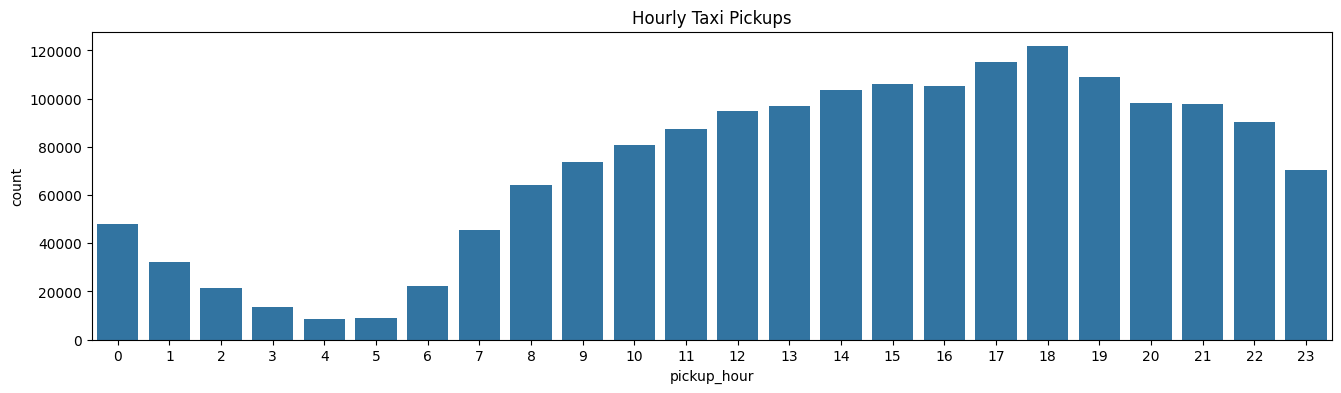

In [29]:
# Load cleaned data
file_path = '/content/drive/MyDrive/cleaned_trip_data.parquet'
df = pd.read_parquet(file_path)

# Convert datetime columns
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Feature engineering
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Filter bad entries (remove outliers)
df_cleaned = df[
    (df['trip_distance'] > 0.1) &
    (df['fare_amount'] > 1) &
    (df['total_amount'] > 1) &
    (df['trip_duration'] > 1) &
    (df['fare_amount'] < 200) &
    (df['trip_distance'] < 50) &
    (df['tip_amount'] < 50)
].copy()

# Categorization
categorical_vars = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type']
temporal_vars = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'pickup_hour']
numerical_vars = ['passenger_count', 'trip_distance', 'trip_duration']
monetary_vars = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

# TEMPORAL ANALYSIS
plt.figure(figsize=(16, 4))
sns.countplot(x='pickup_hour', data=df_cleaned)
plt.title('Hourly Taxi Pickups')
plt.show()

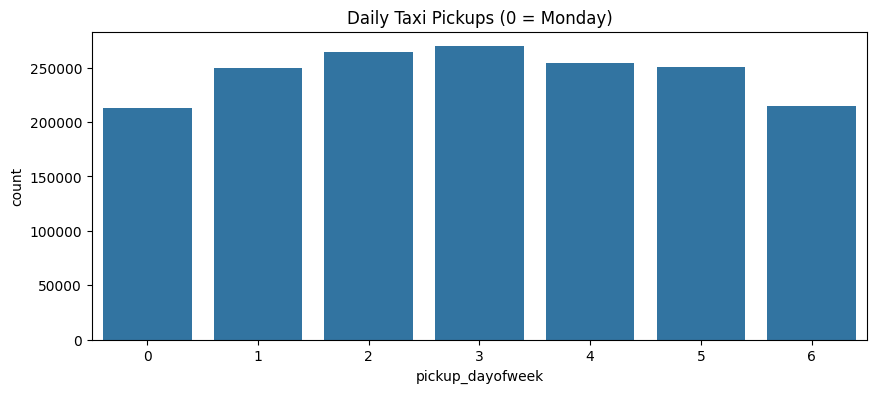

In [30]:
# Find and show the daily trends in taxi pickups (days of the week)
plt.figure(figsize=(10, 4))
sns.countplot(x='pickup_dayofweek', data=df_cleaned)
plt.title('Daily Taxi Pickups (0 = Monday)')
plt.show()

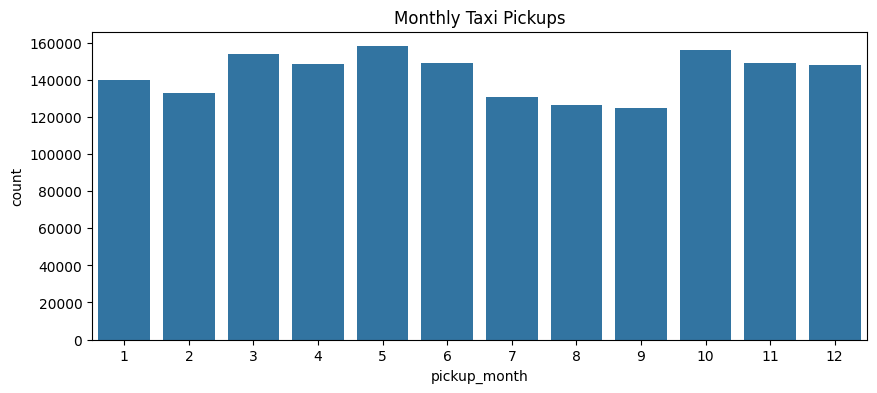

In [31]:
# Show the monthly trends in pickups
plt.figure(figsize=(10, 4))
sns.countplot(x='pickup_month', data=df_cleaned)
plt.title('Monthly Taxi Pickups')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [32]:
# Analyse the above parameters
#FINANCIAL ANALYSIS
print("\nNegative/Zero Values in Key Financial Columns (after cleaning):")
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    print(f"{col}: {(df_cleaned[col] <= 0).sum()} zero/negative values")


Negative/Zero Values in Key Financial Columns (after cleaning):
fare_amount: 0 zero/negative values
tip_amount: 370821 zero/negative values
total_amount: 0 zero/negative values
trip_distance: 0 zero/negative values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [33]:
# Create a df with non zero entries for the selected parameters.
# Select parameters of interest
selected_columns = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'trip_duration']

# Create df_nonzero by keeping only rows where all selected columns are non-zero
df_nonzero = df_cleaned[
    (df_cleaned[selected_columns] > 0).all(axis=1)
].copy()

# Show basic info
print(f"Shape of df_cleaned: {df_cleaned.shape}")
print(f"Shape of df_nonzero: {df_nonzero.shape}")

Shape of df_cleaned: (1716058, 23)
Shape of df_nonzero: (1345237, 23)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

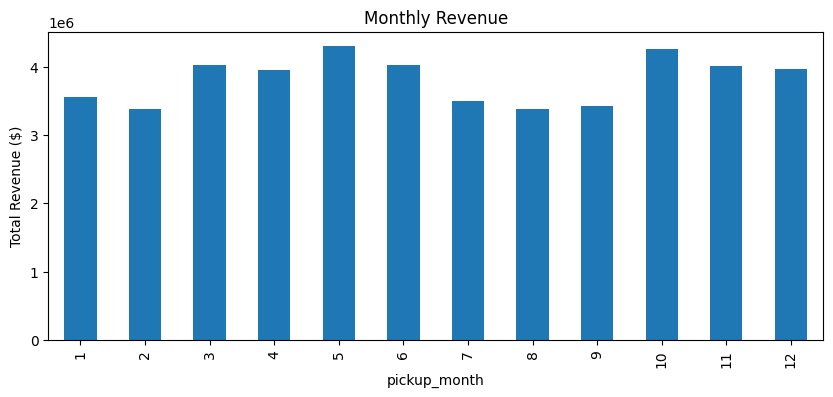

In [34]:
# Group data by month and analyse monthly revenue
# Monthly revenue trend
monthly_revenue = df_cleaned.groupby('pickup_month')['total_amount'].sum()
monthly_revenue.plot(kind='bar', title='Monthly Revenue', figsize=(10, 4))
plt.ylabel("Total Revenue ($)")
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

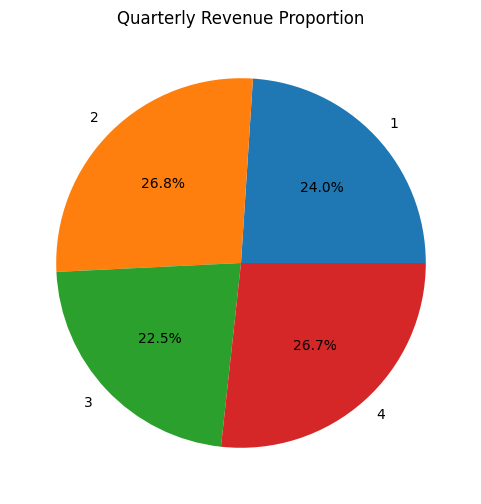

In [35]:
# Calculate proportion of each quarter
# Quarterly revenue proportion
df_cleaned['quarter'] = df_cleaned['tpep_pickup_datetime'].dt.quarter
quarter_revenue = df_cleaned.groupby('quarter')['total_amount'].sum()
quarter_revenue = quarter_revenue / quarter_revenue.sum()
quarter_revenue.plot(kind='pie', autopct='%1.1f%%', title='Quarterly Revenue Proportion', figsize=(6, 6))
plt.ylabel("")
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

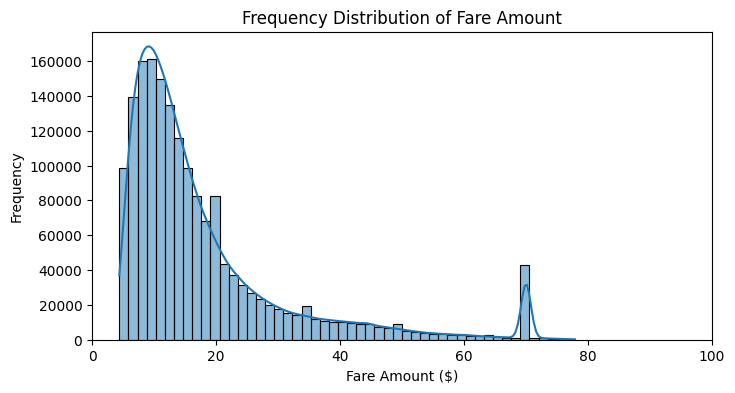

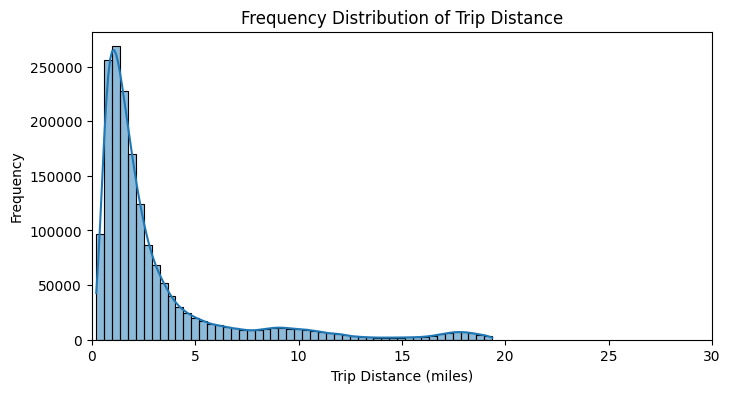

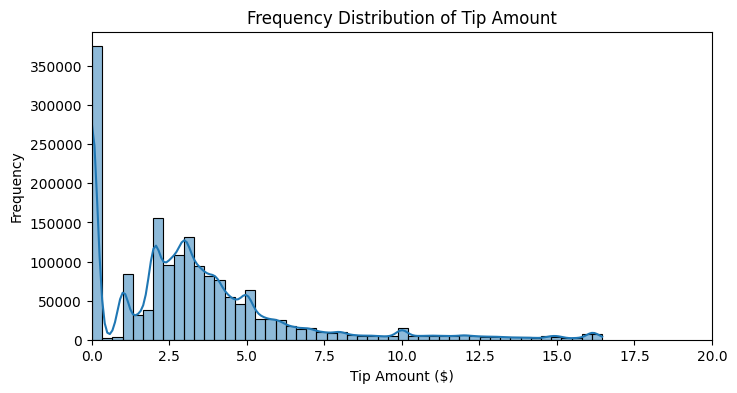

In [36]:
# DISTRIBUTIONS
# Fare Amount Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['fare_amount'], bins=50, kde=True)
plt.title('Frequency Distribution of Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, 100)
plt.show()

# Trip Distance Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['trip_distance'], bins=50, kde=True)
plt.title('Frequency Distribution of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.xlim(0, 30)
plt.show()

# Tip Amount Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['tip_amount'], bins=50, kde=True)
plt.title('Frequency Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

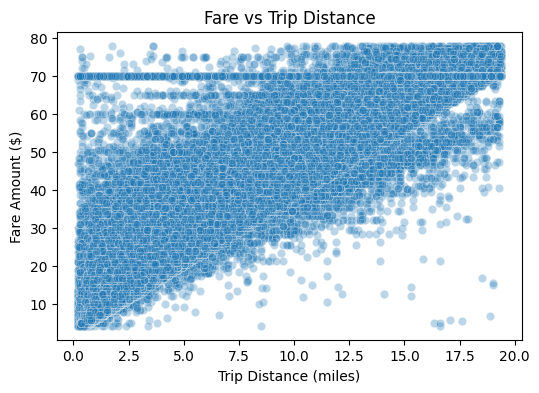

Correlation (trip_distance vs fare_amount): 0.9602315088840627


In [37]:
# Show how trip fare is affected by distance
# Fare vs Distance
plt.figure(figsize=(6, 4))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_cleaned, alpha=0.3)
plt.title('Fare vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()
print("Correlation (trip_distance vs fare_amount):", df_cleaned['trip_distance'].corr(df_cleaned['fare_amount']))

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

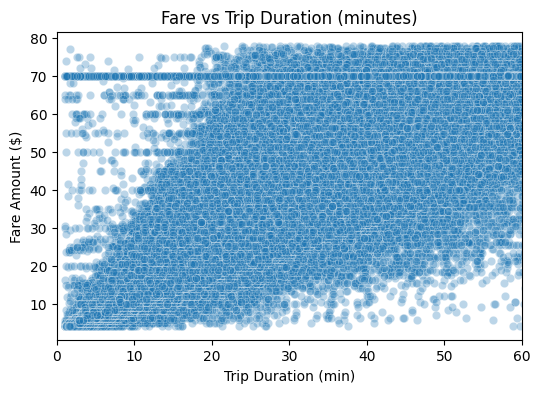

In [38]:
# Show relationship between fare and trip duration
plt.figure(figsize=(6, 4))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_cleaned, alpha=0.3)
plt.title('Fare vs Trip Duration (minutes)')
plt.xlabel('Trip Duration (min)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 60)
plt.show()

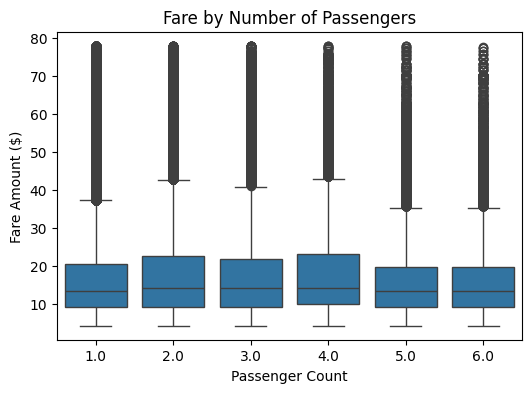

In [39]:
# Show relationship between fare and number of passengers
# Fare vs Passenger Count
plt.figure(figsize=(6, 4))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_cleaned)
plt.title('Fare by Number of Passengers')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.show()

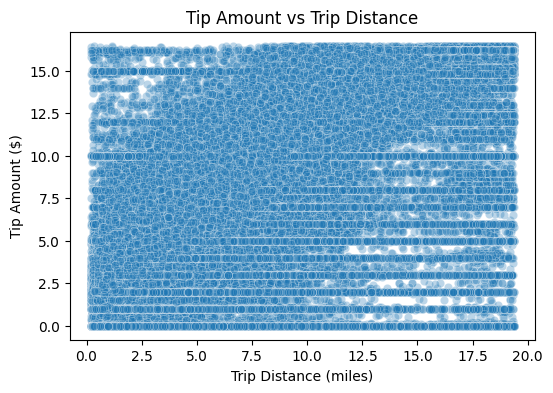

In [40]:
# Show relationship between tip and trip distance
plt.figure(figsize=(6, 4))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_cleaned, alpha=0.3)
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

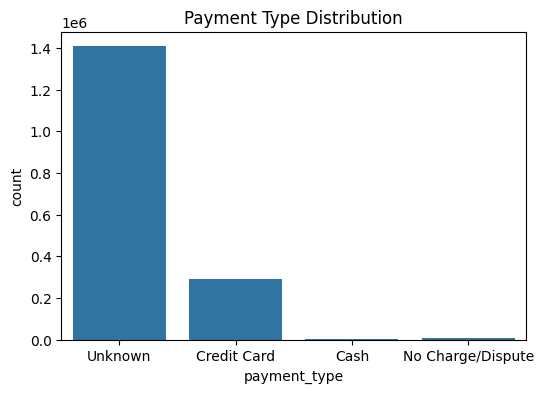

In [41]:
# Analyse the distribution of different payment types (payment_type).
# Payment type distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='payment_type', data=df_cleaned)
plt.title('Payment Type Distribution')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Unknown', 'Credit Card', 'Cash', 'No Charge/Dispute'])
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
import geopandas as gpd

#Load Taxi Zone Shapefile

zones = gpd.read_file('/content/drive/MyDrive/taxi_zones/taxi_zones.shp')
print(zones.info())
zones.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [44]:
# print(zones.info())
# zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID
#Group Trip Data by Pickup Location
#We'll use the same cleaned trip data as before
trip_counts = df_cleaned.groupby('PULocationID').size().reset_index(name='trip_count')
trip_counts.head()

#Merge Zones with Trip Data
zones_trips = zones.merge(trip_counts, how='left', left_on='LocationID', right_on='PULocationID')


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [46]:
# Group data by location and calculate the number of trips
#Group Trip Data by Pickup Location


#Fill missing trip counts with 0
zones_trips['trip_count'] = zones_trips['trip_count'].fillna(0).astype(int)

#Sort zones by trip_count to find busiest zones
zones_trips_sorted = zones_trips.sort_values(by='trip_count', ascending=False)
zones_trips_sorted[['LocationID', 'zone', 'borough', 'trip_count']].head(10)


,LocationID,zone,borough,trip_count
236,237,Upper East Side South,Manhattan,83970
160,161,Midtown Center,Manhattan,82414
235,236,Upper East Side North,Manhattan,74861
131,132,JFK Airport,Queens,63858
161,162,Midtown East,Manhattan,63105
185,186,Penn Station/Madison Sq West,Manhattan,61033
137,138,LaGuardia Airport,Queens,59196
141,142,Lincoln Square East,Manhattan,58684
229,230,Times Sq/Theatre District,Manhattan,57840
169,170,Murray Hill,Manhattan,52198


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [47]:
# Merge trip counts back to the zones GeoDataFrame




The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

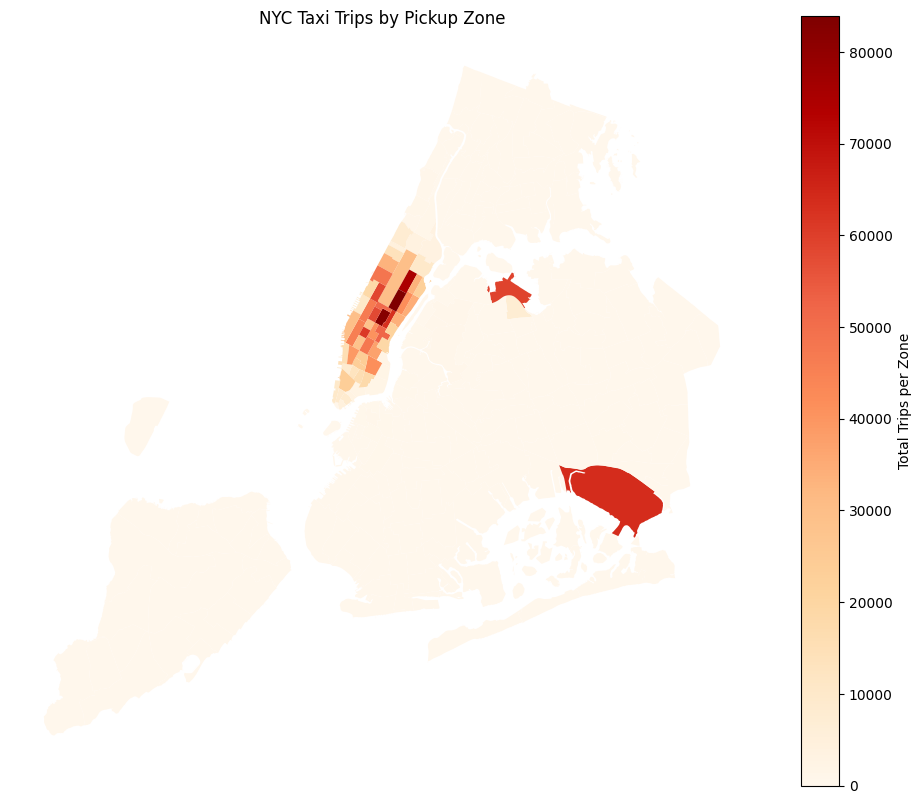

In [48]:
# Define figure and axis


# Plot the map and display it

#Plot Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_trips.plot(column='trip_count',
                 ax=ax,
                 legend=True,
                 cmap='OrRd',
                 legend_kwds={'label': "Total Trips per Zone", 'orientation': "vertical"})

ax.set_title("NYC Taxi Trips by Pickup Zone")
ax.axis('off')  #turn off the axis
plt.show()

In [49]:
# can you try displaying the zones DF sorted by the number of trips?



Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [50]:
# Find routes which have the slowest speeds at different times of the day
#Ensure datetime columns
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

#Create time-related features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
df['trip_duration_mins'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

#Identify slowest routes by hour
avg_duration = df.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['trip_duration_mins'].mean().reset_index()
avg_distance = df.groupby(['PULocationID', 'DOLocationID'])['trip_distance'].mean().reset_index()

#Merge to calculate average speed = distance / duration
route_speed = pd.merge(avg_duration, avg_distance, on=['PULocationID', 'DOLocationID'])
route_speed['avg_speed_mph'] = route_speed['trip_distance'] / (route_speed['trip_duration_mins'] / 60)
slowest_routes = route_speed.sort_values(by='avg_speed_mph').head(10)

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

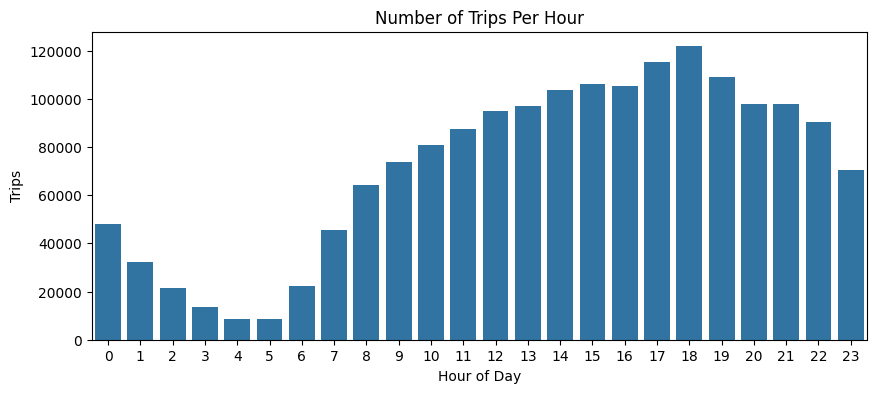

Busiest Hour: 18 with 121738 trips


In [51]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = df.groupby('pickup_hour').size()
plt.figure(figsize=(10, 4))
sns.barplot(x=trips_per_hour.index, y=trips_per_hour.values)
plt.title("Number of Trips Per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trips")
plt.xticks(range(24))
plt.show()

busiest_hour = trips_per_hour.idxmax()
print(f"Busiest Hour: {busiest_hour} with {trips_per_hour[busiest_hour]} trips")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [52]:
#Scale trip counts using sample fraction
sample_fraction = 0.05
scaled_trips = trips_per_hour.sort_values(ascending=False).head(5) / sample_fraction
print("Scaled trip counts for 5 busiest hours:")
print(scaled_trips)

Scaled trip counts for 5 busiest hours:
pickup_hour
18    2434760.0
17    2305620.0
19    2181660.0
15    2125000.0
16    2101920.0
dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

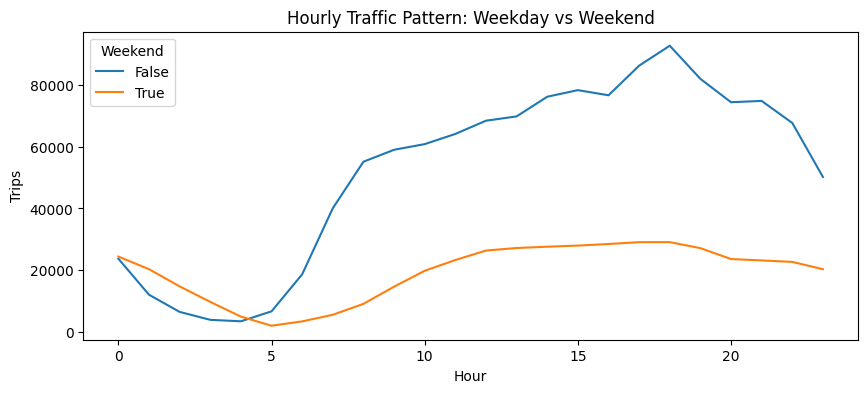

In [53]:
# Compare traffic trends for the week days and weekends
df['is_weekend'] = df['pickup_day'].isin([5, 6])
week_pattern = df.groupby(['pickup_hour', 'is_weekend']).size().reset_index(name='trips')
plt.figure(figsize=(10, 4))
sns.lineplot(data=week_pattern, x='pickup_hour', y='trips', hue='is_weekend')
plt.title("Hourly Traffic Pattern: Weekday vs Weekend")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend(title="Weekend")
plt.show()

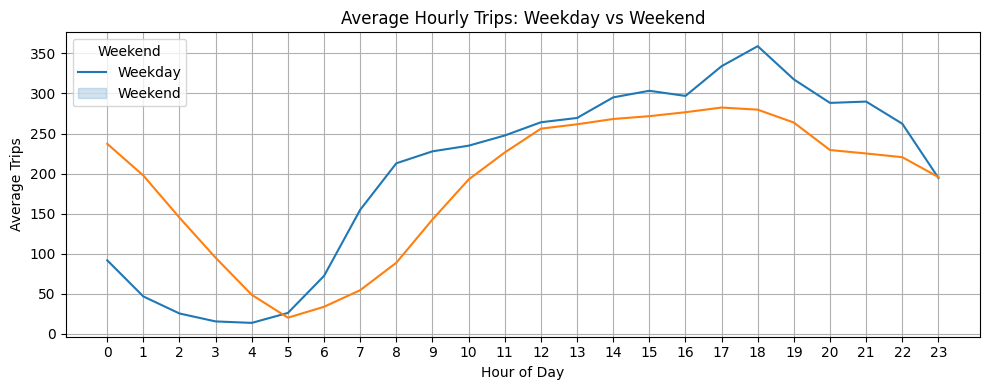

In [54]:
# Mark weekends (Saturday=5, Sunday=6)
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6])

# Add day as a string (to help average over same weekdays/weekends)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.date

# Group by hour, weekend/weekday, and date to compute daily trip counts
daily_hourly_trips = df.groupby(['pickup_day', 'pickup_hour', 'is_weekend']).size().reset_index(name='trip_count')

# Now compute the average trip count per hour across days
avg_hourly_trips = daily_hourly_trips.groupby(['pickup_hour', 'is_weekend'])['trip_count'].mean().reset_index()

# Plotting
plt.figure(figsize=(10, 4))
sns.lineplot(data=avg_hourly_trips, x='pickup_hour', y='trip_count', hue='is_weekend')
plt.title("Average Hourly Trips: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trips")
plt.legend(title="Weekend", labels=['Weekday', 'Weekend'])
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Finding the busy and quite hours helps ud to determine the number of taxis that need to be present in a certain pick-up location at anygiven time and control fare prices from becoming too high.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

Top 10 Pickup Zones:
 PULocationID
237    83976
161    82422
236    74870
132    63888
162    63110
186    61038
138    59207
142    58685
230    57848
170    52203
Name: count, dtype: int64
Top 10 Dropoff Zones:
 DOLocationID
236    78180
237    74637
161    68421
230    52824
170    52125
162    50037
142    49314
239    48522
141    46541
68     44241
Name: count, dtype: int64


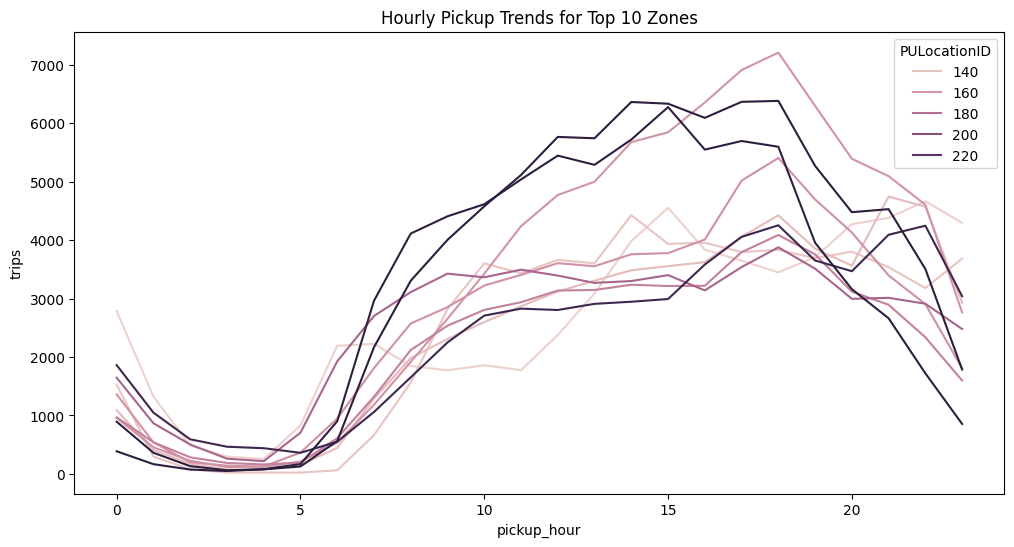

In [55]:
# Find top 10 pickup and dropoff zones
top_pickups = df['PULocationID'].value_counts().head(10)
top_dropoffs = df['DOLocationID'].value_counts().head(10)
print("Top 10 Pickup Zones:\n", top_pickups)
print("Top 10 Dropoff Zones:\n", top_dropoffs)

#Plot trends for top pickup zones
top_zones = top_pickups.index.tolist()
pickup_trends = df[df['PULocationID'].isin(top_zones)].groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='trips')
plt.figure(figsize=(12, 6))
sns.lineplot(data=pickup_trends, x='pickup_hour', y='trips', hue='PULocationID')
plt.title("Hourly Pickup Trends for Top 10 Zones")
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [56]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df['PULocationID'].value_counts().rename('pickup_count')
dropoff_counts = df['DOLocationID'].value_counts().rename('dropoff_count')
zone_ratios = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)
zone_ratios['ratio'] = zone_ratios['pickup_count'] / (zone_ratios['dropoff_count'] + 1e-5)


print("\nTop 10 Pickup/Dropoff Ratios:\n", zone_ratios.sort_values(by='ratio', ascending=False).head(10))
print("\nBottom 10 Pickup/Dropoff Ratios:\n", zone_ratios.sort_values(by='ratio').head(10))


Top 10 Pickup/Dropoff Ratios:
      pickup_count  dropoff_count          ratio
44            2.0            0.0  200000.000000
199           2.0            0.0  200000.000000
84            1.0            0.0  100000.000000
70         7532.0          761.0       9.897503
132       63888.0        12647.0       5.051633
138       59207.0        19957.0       2.966728
204           2.0            1.0       1.999980
186       61038.0        38392.0       1.589862
114       23382.0        16861.0       1.386750
43        29613.0        21492.0       1.377862

Bottom 10 Pickup/Dropoff Ratios:
      pickup_count  dropoff_count  ratio
99            0.0            1.0    0.0
109           0.0            2.0    0.0
187           0.0            3.0    0.0
221           0.0            7.0    0.0
30            0.0           18.0    0.0
184           0.0           17.0    0.0
118           0.0           11.0    0.0
245           0.0            6.0    0.0
27            0.0           24.0    0.0
251  

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [57]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
#Night hours: Top pickup/dropoff zones (11PM–5AM)
df['hour'] = df['pickup_hour']
night_df = df[(df['hour'] >= 23) | (df['hour'] <= 5)]

top_night_pickups = night_df['PULocationID'].value_counts().head(10)
top_night_dropoffs = night_df['DOLocationID'].value_counts().head(10)
print("Top Night Pickup Zones:\n", top_night_pickups)
print("Top Night Dropoff Zones:\n", top_night_dropoffs)

Top Night Pickup Zones:
 PULocationID
79     15052
249    12122
132    10272
48     10098
148     9347
114     8510
230     7811
186     6682
164     5900
68      5785
Name: count, dtype: int64
Top Night Dropoff Zones:
 DOLocationID
79     7973
48     6573
170    6033
68     5572
107    5550
141    5076
263    4781
249    4706
230    4347
229    4232
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [58]:
# Filter for night hours (11 PM to 5 AM)
day_df = df[(df['hour'] > 5) & (df['hour'] < 23)]
night_revenue = night_df['total_amount'].sum()
day_revenue = day_df['total_amount'].sum()

print(f"Nighttime Revenue Share: {night_revenue / (night_revenue + day_revenue):.2%}")
print(f"Daytime Revenue Share: {day_revenue / (night_revenue + day_revenue):.2%}")

Nighttime Revenue Share: 12.08%
Daytime Revenue Share: 87.92%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

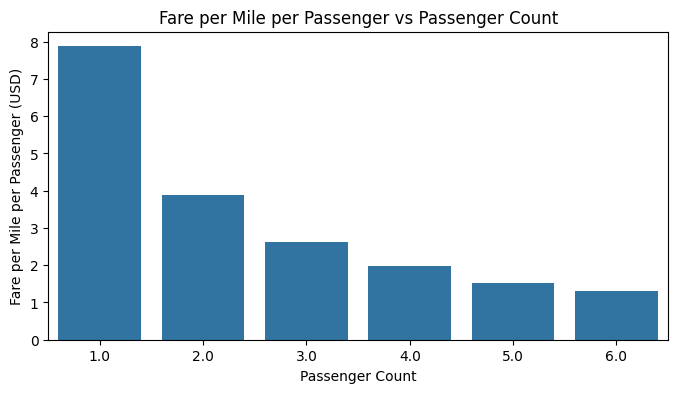

In [59]:
# Analyse the fare per mile per passenger for different passenger counts
#Calculate fare per mile (avoid zero or invalid distances)
df_valid = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]

#Fare per mile per passenger
df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']
df_valid['fare_per_mile_per_passenger'] = df_valid['fare_per_mile'] / df_valid['passenger_count'].replace(0, np.nan)

passenger_fare = df_valid.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=passenger_fare, x='passenger_count', y='fare_per_mile_per_passenger')
plt.title("Fare per Mile per Passenger vs Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare per Mile per Passenger (USD)")
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

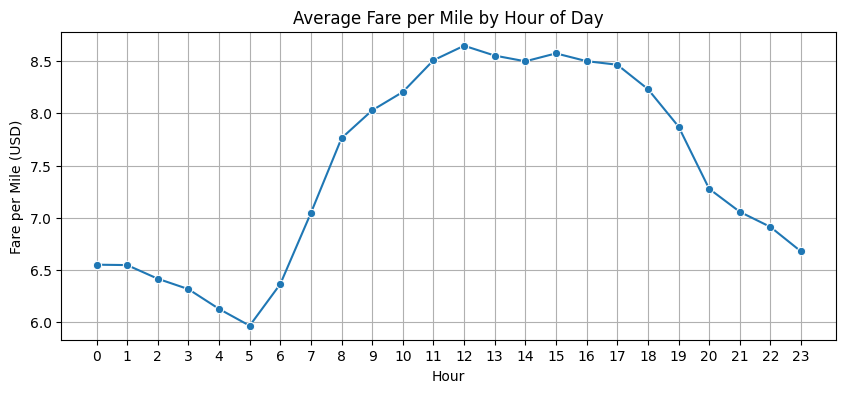

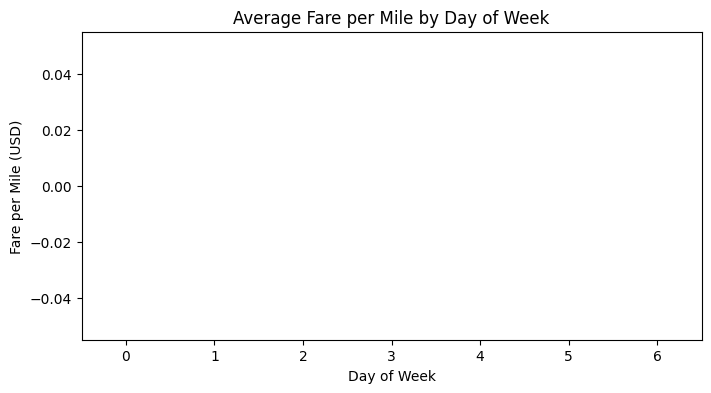

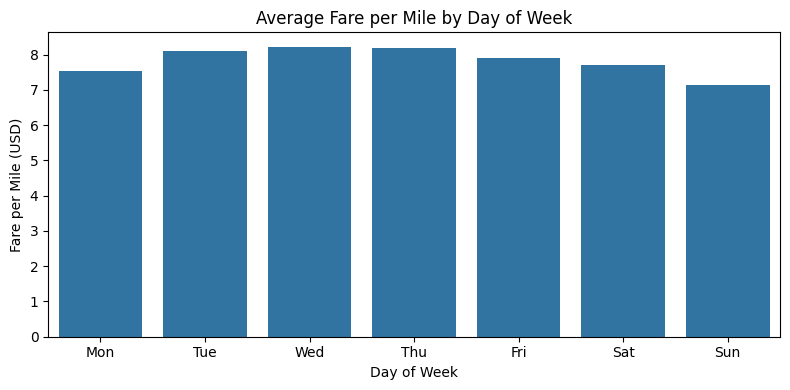

In [70]:
# Compare the average fare per mile for different days and for different times of the day
hourly_fare = df_valid.groupby(df_valid['pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=hourly_fare, x='pickup_hour', y='fare_per_mile', marker='o')
plt.title("Average Fare per Mile by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fare per Mile (USD)")
plt.xticks(range(24))
plt.grid(True)
plt.show()


#Average fare per mile by day of week

weekday_fare = df_valid.groupby(df_valid['pickup_dayofweek'])['fare_per_mile'].mean().reset_index()
weekday_fare['pickup_day'] = weekday_fare['pickup_dayofweek'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
})

plt.figure(figsize=(8, 4))
sns.barplot(data=weekday_fare, x='pickup_day', y='fare_per_mile', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fare per Mile (USD)")
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

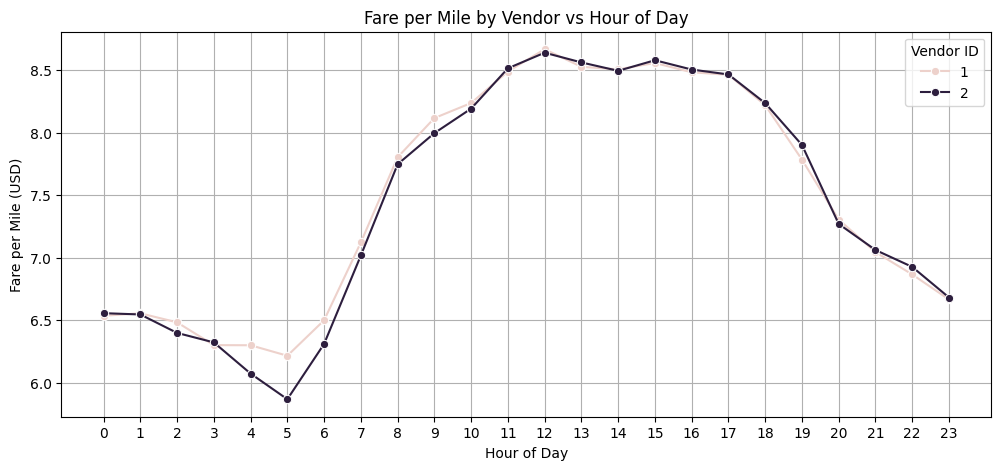

In [61]:
# Compare fare per mile for different vendors
vendor_hour_fare = df_valid.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=vendor_hour_fare, x='pickup_hour', y='fare_per_mile', hue='VendorID', marker='o')
plt.title("Fare per Mile by Vendor vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fare per Mile (USD)")
plt.xticks(range(24))
plt.grid(True)
plt.legend(title='Vendor ID')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


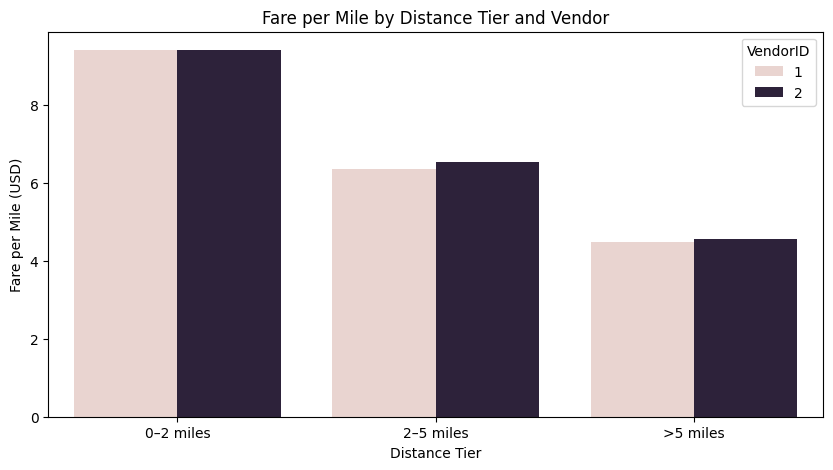

In [62]:
# Defining distance tiers
#Fare per mile by distance tiers
def distance_tier(d):
    if d <= 2:
        return '0–2 miles'
    elif 2 < d <= 5:
        return '2–5 miles'
    else:
        return '>5 miles'

df_valid['distance_tier'] = df_valid['trip_distance'].apply(distance_tier)

#Compare fare per mile by vendor in each tier
tier_vendor_fare = df_valid.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=tier_vendor_fare, x='distance_tier', y='fare_per_mile', hue='VendorID')
plt.title("Fare per Mile by Distance Tier and Vendor")
plt.xlabel("Distance Tier")
plt.ylabel("Fare per Mile (USD)")
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

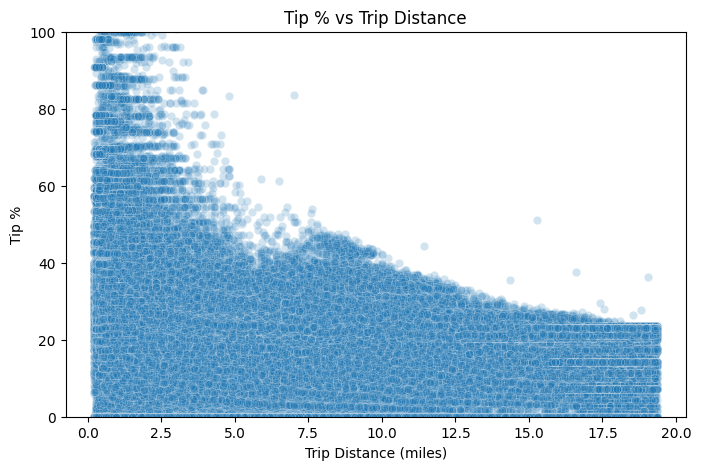

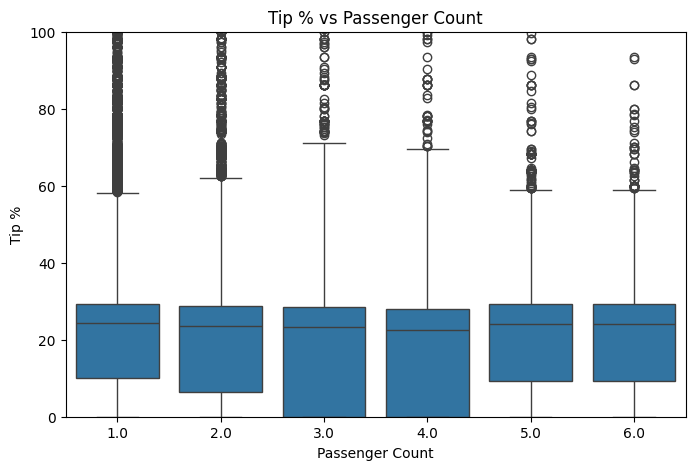

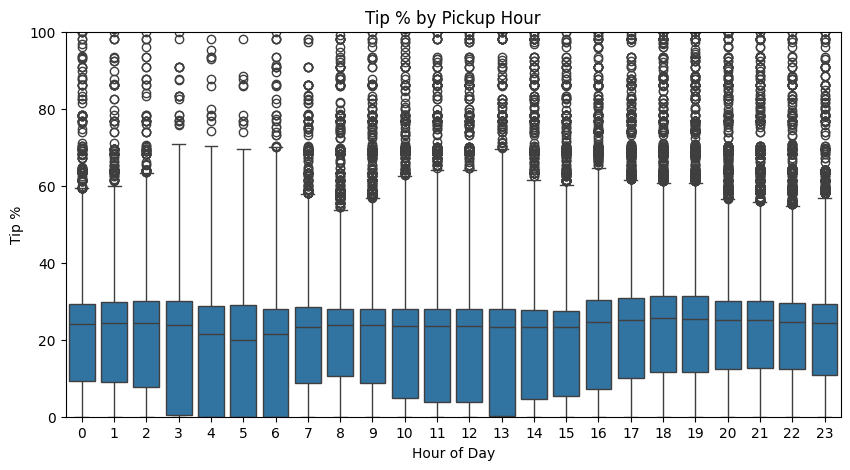

In [63]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
#Compute Tip Percentage
df_valid_tips = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0)]
df_valid_tips['tip_percentage'] = 100 * df_valid_tips['tip_amount'] / df_valid_tips['fare_amount']

#Tip % vs Trip Distance
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_valid_tips, x='trip_distance', y='tip_percentage', alpha=0.2)
plt.title('Tip % vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip %')
plt.ylim(0, 100)
plt.show()

#Tip % vs Passenger Count
plt.figure(figsize=(8,5))
sns.boxplot(data=df_valid_tips, x='passenger_count', y='tip_percentage')
plt.title('Tip % vs Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Tip %')
plt.ylim(0, 100)
plt.show()

#Tip % vs Pickup Hour
plt.figure(figsize=(10,5))
sns.boxplot(data=df_valid_tips, x='pickup_hour', y='tip_percentage')
plt.title('Tip % by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Tip %')
plt.ylim(0, 100)
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [64]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tips = df_valid_tips[df_valid_tips['tip_percentage'] < 10]
high_tips = df_valid_tips[df_valid_tips['tip_percentage'] > 25]

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

Comparison of Low Tip (<10%) vs High Tip (>25%) Trips


,Metric,Low Tip (mean),High Tip (mean)
0,Trip Distance,3.512014,2.073932
1,Passenger Count,1.435897,1.367444
2,Pickup Hour,13.937110,14.624412


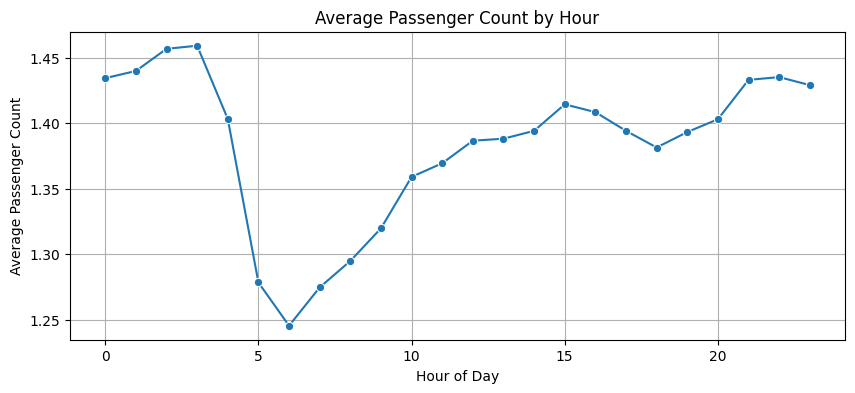

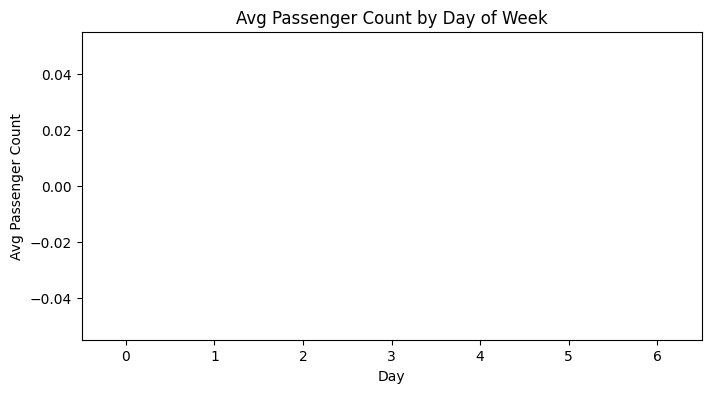

In [65]:
# See how passenger count varies across hours and days
compare_df = pd.DataFrame({
    'Metric': ['Trip Distance', 'Passenger Count', 'Pickup Hour'],
    'Low Tip (mean)': [low_tips['trip_distance'].mean(), low_tips['passenger_count'].mean(), low_tips['pickup_hour'].mean()],
    'High Tip (mean)': [high_tips['trip_distance'].mean(), high_tips['passenger_count'].mean(), high_tips['pickup_hour'].mean()]
})
print("Comparison of Low Tip (<10%) vs High Tip (>25%) Trips")
display(compare_df)

#Passenger count variation by hour
passenger_hourly = df.groupby('pickup_hour')['passenger_count'].mean().reset_index()
plt.figure(figsize=(10,4))
sns.lineplot(data=passenger_hourly, x='pickup_hour', y='passenger_count', marker='o')
plt.title("Average Passenger Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Count")
plt.grid(True)
plt.show()

#Passenger count variation by day of week
passenger_weekday = df.groupby('pickup_day')['passenger_count'].mean().reset_index()
passenger_weekday['pickup_day'] = passenger_weekday['pickup_day'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
})
plt.figure(figsize=(8,4))
sns.barplot(data=passenger_weekday, x='pickup_day', y='passenger_count')
plt.title("Avg Passenger Count by Day of Week")
plt.xlabel("Day")
plt.ylabel("Avg Passenger Count")
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [66]:
# How does passenger count vary across zones
zone_passenger_avg = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
zone_passenger_avg.columns = ['location_id', 'avg_passenger_count']

In [67]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

extra: Applied in 62.14% of trips
mta_tax: Applied in 99.85% of trips
improvement_surcharge: Applied in 100.00% of trips
congestion_surcharge: Applied in 93.93% of trips


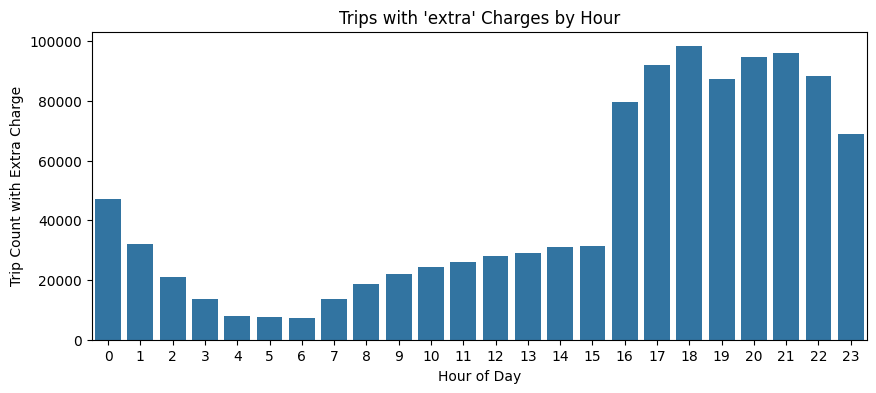

Top 10 Zones with Most Trips Having Extra Charges:


,PULocationID,extra_trip_count
110,138,58497
131,161,52777
194,237,47767
193,236,39238
132,162,39019
187,230,38694
113,142,36881
151,186,35580
133,163,32585
66,79,31984


In [68]:
# How often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge']
for col in surcharge_cols:
    surcharge_rate = (df[col] > 0).mean() * 100
    print(f"{col}: Applied in {surcharge_rate:.2f}% of trips")

#Extra charges by pickup hour
df_surcharge = df[df['extra'] > 0]
extra_hourly = df_surcharge.groupby('pickup_hour').size().reset_index(name='extra_trip_count')

plt.figure(figsize=(10,4))
sns.barplot(data=extra_hourly, x='pickup_hour', y='extra_trip_count')
plt.title("Trips with 'extra' Charges by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count with Extra Charge")
plt.show()

#Top zones with frequent surcharges
surcharge_zones = df[df['extra'] > 0].groupby('PULocationID').size().reset_index(name='extra_trip_count')
top_surcharge_zones = surcharge_zones.sort_values('extra_trip_count', ascending=False).head(10)
print("Top 10 Zones with Most Trips Having Extra Charges:")
display(top_surcharge_zones)

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Busiest Hour: 18 with 121738 trips,
Hours with least trafic is 4 and 5.

Top 10 Pickup Zones:
 PULocationID
237, 161, 236, 132, 162, 186, 138, 142, 230, 170.

Top 10 Dropoff Zones:
 DOLocationID
236, 237, 161, 230, 170, 162, 142, 239, 141, 68.

By looking at the above data we can see that there are repeated locationID in both pick and drop off zones this lets us come to the conclusion most of the trips are within the zone or the zones hold the most amount of coustomers, following the above conclusion we need arrange for more taxies in those locationIDs in order to reduce congestion and reduce the overall fair.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Busiest Hour: 18 with 121738 trips, Busiest Month: May, Busiest Day: Tuesday.

from the above data we can suggest to provide more insentives for the drives in order to make more trips during this period, as during this period the average number of trips is very high and having more number of taxies on road will help reduce extra charges and help with flow of trafic, by providing more supply to the times of heavy demand.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

By looking at the trip frequency vs distance graphs we can tell that the most number of trips fall below 5 miles both vendors provide the same fare per mile in this range in order to compete in this market we need to provide a fare that is slightly less than the other vendors and charge the average between both vendors for trips above 5 miles, by doing this we can break even any losses that were expected in trips below 5 Miles.